# **Methode Monte Carlo: Cours et applications**
by PAKA Fabrice Essinam

 On appelle méthode de Monte-Carlo toute méthode visant à estimer une quantité numérique, difficile à calculer explicitement, à l’aide de procédés probabilistes.

 C'est une methode créer par **Nicholas Metropolis** en 1947. 

 Les methodes Monte Carlo sont multiples:
   - ils sont utiliser dans le calcul d'integrale en dimension superieur à 1 (calcul de surface, volume,...)
   - ils sont utiliser dans la prediction des risques financiers.
   - ils ont des application en physique statistique, dans le nucléaire, ...

## **Comment determiner la superficie d'une surface grace à la méthode Monte Carlo**
 Soit F une surface de $\mathbb{R^2}$ ($F \subset \mathbb{R^2}$ ). On cherche à calculer la valeur de sa superficie.

 Mathématiquement, cette superficie peut etre obtenu en integrant sur la fonction caractéristique $\chi_F(x)$. 
 $$A_F = \int_{\mathbb{R^2}}\chi_F(x) \,dx^2 $$
avec 
$$ \chi_F(x) = \begin{cases}
   1, \quad\text{si}\ x \in F\\
   0, \quad\text{sinon}\
   \end{cases}
$$
 - En pratique pour faire ce calcul:

   1. on insère F dans un rectangle R dont on connais la superficie $A_R$. 

   2. on discretise la surface du rectangle R en N element de surfaces enrobant N points distinct. La superficie moyenne de chaque élement de surface est donnée par $A_i = \frac{A_R}{N}$ 

   3. Trouver la superficie de F revient à sommer tous les elements de surface qui se trouvent dans F:
        $$
        \begin{align*} 
          A_F &= \sum_{i = 1}^N A_{i;F}  \\ 
          A_F  &=  \sum_{i = 1}^N A_{i}\chi_F(x_i)
       \end{align*}
        $$

   4. En remplaçant $A_i$ par son expression dans l'expression précédente on obtient:

      $$ 
      A_F \approx \frac{A_R}{N}\sum_{i = 1}^N \chi_F(x_i)
      $$

   5. La methode Monte carlo entre en jeux à cette étape. Pour calculer la partie $\sum_{i = 1}^N \chi_F(x_i)$, on fait agit comme suit:
       - On tire au hasard $N$ points dans le rectangle
       - On classify chaque point tiré suivant qu'il soit à l'interieur ou à l'exterieur de notre surface
       - On compte ensuite tous les points à l'interieur de la surface, on obtient alors 
       $$
       \sum_{i = 1}^N \chi_F(x_i) = N_F
       $$

   6. La superficie de la surface $F$ est donnée par: 
        $$ 
      A_F \approx \frac{A_R N_F}{N}
      $$ 

### Estimation de la valeur de pi par le calcul de l'aire d'un quart de disque

Pour estimer la valeur de Pi, on considère le quart de disque de rayon r = 1 dans le premier quadrant $0<x;y<1$

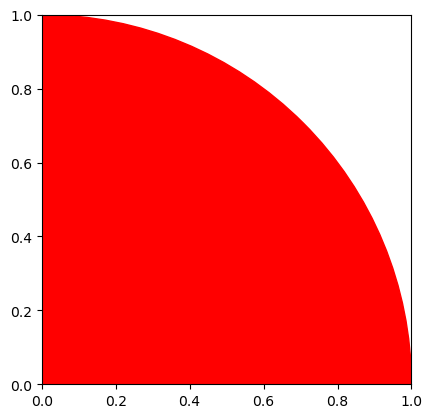

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches
from matplotlib.collections import PatchCollection
import numpy as np

circle = matplotlib.patches.Circle((0,0), 1)
collections = PatchCollection([circle], color="red")

ax = plt.subplot()
ax.set_aspect(1)
ax.add_collection(collections);


Le protocole de calcul de l'aire du quart du cercle par la méthode Monte Carlo est la suivante:

  1. Inclure le quart de disque dans un carré de coté 1 ; le carré $[0, 1] \times [0, 1]$.
  2. Generer un point x_i au hasard
  3. Classer le point selon qu'il soit à l'interieur du disque (partie rouge de la figure ci-dessus) ou a l'exterieur du disque (partie blanche de la figure ci-dessus)

  $$
   x_i = \begin{cases}
   1, \quad\text{si}\ \sqrt{x^2 + y^2} \le 1\\
   0, \quad\text{si}\ \sqrt{x^2 + y^2} > 1
   \end{cases}
   $$  
  4. Repeter les etapes 2 et 3 en boucle $N$ fois 
  5. L'aire rechercher est donner par le rapport du nombre de points à l'interieur ($N_{inside}$) de la surface et du nombre total de points $N$ des points :
   $$ 
   \begin{align*} 
      A_{quart-cercle} \approx& \frac{A_{carré} N_{inside}}{N}\\
      A_{quart-cercle} \approx & \frac{N_{inside}}{N}

    \end{align*} 
  $$ 

puisque  $A_{carré} = 1\times 1 = 1$

On endeduit ensuite l'estimation de $\pi$ par la formule de l'aire d'un disque:
$$ 
   \begin{align*} 
     A_{quart-cercle} =& \frac{A_{cercle}}{4} =& \frac{\pi}{4}
    \end{align*}
$$ 

$$
\pi = 4\times A_{quart-cercle} 
$$



In [11]:
point_interieur = []
point_exterieur = []
N_interieur = 0
N_total  = 1000000
N_simulation = 10
i = 0
k = 0
Aire_quart_cercle = 0
while k < N_simulation:
  while i < N_total:  
      x = np.random.random()
      y = np.random.random()
      if np.sqrt(x**2 +y**2) < 1:
          N_interieur += 1
          point_interieur.append((x,y))
      else:
          point_exterieur.append((x,y))
      i += 1
  Aire_quart_cercle += N_interieur/N_total
  k += 1
Aire_quart_cercle = Aire_quart_cercle/N_simulation 
pi = 4*Aire_quart_cercle 
print(f"Aire du  quart du disque = {Aire_quart_cercle}")
print(f"Estimation de Pi est donc = {pi}")
print(f"Erreur d'estimation = {np.abs(np.pi -pi)}" )

Aire du  quart du disque = 0.7854400000000001
Estimation de Pi est donc = 3.1417600000000006
Erreur d'estimation = 0.00016734641020743624


### Calcul d'une integrale grace à la methode Monte Carlo

L'idée de base est pour calculer une integrale(problème deterministe) est de le transformer en la valeur moyenne d'un processus aléatoire (problème probabiliste).

Soit l'integrale suivante:

$$\theta = \int_{a}^{b}f(x) \,dx$$

Nous allons faire une transformation de cette integrale en passant des bornes $[a;b]$ aux bornes $[0;1]$

**changement de bornes de l'integrale theta**

$$
\begin{align*}
   0 \le & t \le 1\\
   (b - a) \times 0\le & (b - a) \times t  \le (b - a) \times 1  & \text{en multipliant par (b - a)} \\
   0\le & (b - a)t  \le b - a\\
   0 +a \le & (b - a)t + a  \le  b - a + a   & \text{en ajoutant par a} \\
   a \le & (b - a)t + a  \le  b
\end{align*}
$$
on endeduit alors que $x =  (b - a)t + a$. 

$dx = (b-a)dt$

Lorsque  $ x \rightarrow a$; $t \rightarrow 0$

Lorsque $ x \rightarrow b$; $t \rightarrow 1$ 

en effectuant le changement de variables on obtien l'integrale devient alors $$ \theta = \int_{0}^{1}f\left((b - a)t + a\right)\, (b-a)dt$$
soit $$\theta =(b-a) \int_{0}^{1}f\left((b - a)t + a\right)\,dt$$
posons $g(t) = f\left((b - a)t + a\right)$
$$
\theta =(b-a) \int_{0}^{1}g(t)\,dt
$$

**Introduction du hasard**

 nous allons à present penser $\int_{0}^{1}g(t)\,dt$  comme une esperance mathématique E(g(X)) de la variable aleatoire $g(X)$. On considère pour cela la variable $t$ comme une variable aléatoire qu'on va noté à present $X$ qui prend ses valeurs sur $[0;1]$ de fonction de densité $h(x)$

 $$
 \begin{align*}
  E(g(X)) =& \int_{-\infty}^{\infty}g(x)h(x)\,dx\\
  E(g(X)) =& \int_{0}^{1}g(x)h(x)\,dx     & \text{puisque $h$ est défini sur $[0;1]$}\\
  E(g(X)) =&  \int_{0}^{1}g(x)\cdot 1\,dx  & \text{par identification avec $\int_{0}^{1}g(t)\,dt$}\\
  E(g(X)) =&  \int_{-\infty}^{\infty}g(x) \mathbb{1}_{[0;1]}\,dx
 \end{align*}
 $$
$f(x)$ est donc une loi uniforme definie sur $[0;1]$. elle est definie comme suit:

$$f(x) =\begin{cases}

1 , \quad  \text{si}  0 \le x \le 1\\
0 , \quad \text{ailleurs}

\end{cases}
$$
 Nous venons de transformer un problème qui à la base était deterministe et difficile à resoudre en un problème probabiliste facile à resoudre.
 Pour calculer $\theta$ il suffit donc d'estimer sa valeur par l'expression suivantes
 $$\theta = (b-a)E(g(X)) \text{  avec $X$ une variable aleatoire qui suit une loi uniforme sur $[0;1]$}
 $$

 **Estimateur de Monte carlo**

 L'estimation de l'integrale se fait grace à l'estimateur de Monte Carlo noté $\hat{\theta}_{MC}$. Cette estimateur calcul l'esperance mahématique comme la moyenne arithmétique de $N$ mésures identiquement distribués.
$$
\theta \approx \hat{\theta}_{MC}\\
       \approx (b-a) [\frac{g(x_1)+g(x_2)+g(x_3)+\cdots+g(x_N)}{N}]\\
\theta \approx \hat{\theta}_{MC} = \frac{(b-a)}{N}\sum_{i=1}^{N}g(x_i)
$$

**Recapitulatif de la methode de calcul Monte Carlo pour le calcul d'une integral**

Soit l'integrale suivante: $$\theta = \int_{a}^{b}f(x) \,dx$$


1. Changement des bornes de l'integrale
$$
\theta =(b-a) \int_{0}^{1}g(t)\,dt   \text{   avec $g(t) = f(a+(b-a)t)$}
$$
 
2. Introduction du hasard et estimation de theta grace a l'estimateur de Monte Carlo

   - on choisit aleatoirement $x_i$  en suivant la loi uniforme sur $[0;1]$

   - on calcul $g(x_i)$

   - on repète les étapes précédentes N fois

   - on estime alors $\theta$ comme la moyenne arithmétique (empirique) sur les $g(x_i)$ multiplié par $(b-a)$

$$
\theta \approx \hat{\theta}_{MC}= \frac{(b-a)}{N}\sum_{i=1}^{N}g(x_i)
$$

En dimension plus élevée $d$ par exemple, si $R$ est une région en $d$ dimensions avec volume $V_R$ , on a
l’approximation Suivante:
$$
\int_{R}f(\vec{x}) \,d^{d}x \approx \frac{V_R}{N} \sum_{i=1}^{N}g(\vec{x}_i)
$$
ou \vec{x_i} represente ls coordonnées d'un point i en dimension d

Calculons l'integrale suivante:
$$
I = \int_{-1}^{3} e^{-t^2} \,dt
$$

1. Changement des bornes de l'integrale

  $I = 4\int_{0}^{1} e^{-(-1+4x)^2}\,dx$

2. Integration du hasard
  on definit la variable aleatoir $X =\left\{x_1; x_2; x_3; \cdots;x_N \right\}$ 
  
  qui suit une loi uniforme definie sur $[0;1]$. 
  $$I = \hat{I}_{MC} = \frac{4}{N} \times \sum_{i=1}^N e^{-(-1+4x_i)^2}$$

3. Pour calculer précisement la valeur de l'integrale, on doit tirer aleatoirement un nombre élevés $N$  de valeurs $x_i$ entre $[0;1]$. Cela ne peut se faire à l'aide d'un programme tel que Python.


In [14]:
import numpy as np 
# Fonction à integrer 
def f(x):
    return np.exp(-x**2)

# Fonction qui effectue l'estimation Monte Carlo de l'Integrale
def integration_MC(N, b, a, f):
    """ 
    Cette fonction permet d'approximer la valeur de n'importe quelle integrale en une dimension.
    
    Entrée
    ------                                                  
    N: nombre totale d'echantillons        a: borne inferieur de l'integrale
    b: Borne superieur de l'integrale      f: la fonction à intégrer

    Sortie
    ------
    la valeur de l'integrale
    """
    somme_x_i = 0
    v = b-a
    i = 0
    while i < N:
        x = np.random.random()
        x_i = -1+4*x  
        f_xi = f(x_i)
        somme_x_i += f_xi
        i += 1
    return v*somme_x_i/N

# Estimation de l'integrale:
a = -1; b = 3; N = 100000
I = integration_MC(N, b, a, f)
print(f"L'estimation de I par Monte Carlo est donc: {I}")
 

L'estimation de I par Monte Carlo est donc: 1.6314977958702275


#### lien important
[Monte carlo cinetique](https://www.techno-science.net/glossaire-definition/Methode-de-Monte-Carlo-cinetique-page-2.html)

[Explication Monte carlo](https://fr-academic.com/dic.nsf/frwiki/1153012)

### Resources
